# S2 Coursework
fl482

### Import dependencies

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, gamma
from scipy.stats import gaussian_kde
import scipy.integrate as integrate
import emcee
import corner
import dynesty


## Exercise 1: Accident Data

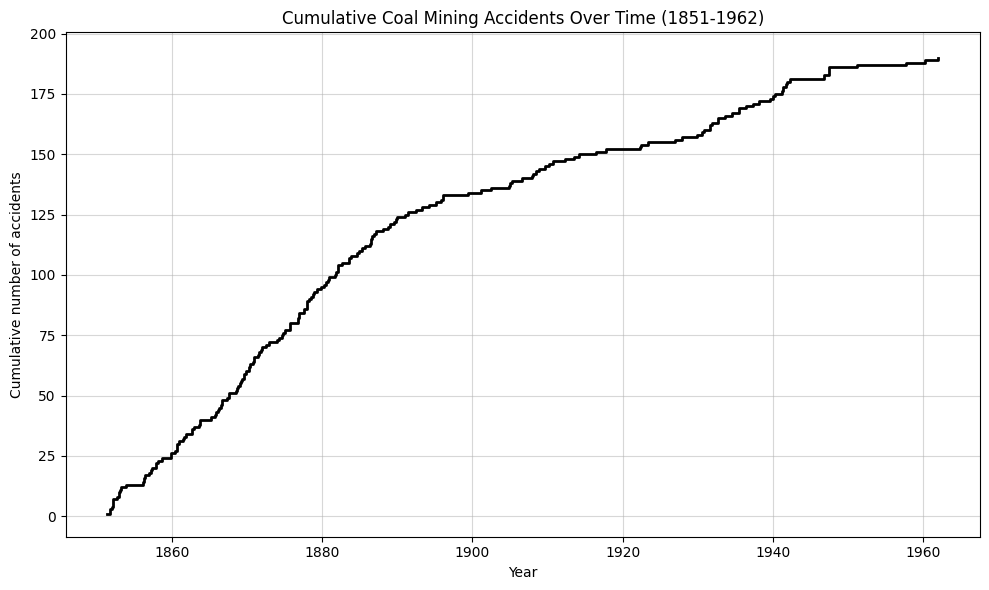

Total number of accidents (N): 191
Total period in days (L): 40550
Mean rate of accidents: 0.004710 accidents/day
Mean rate of accidents: 1.72 accidents/year


In [3]:
# load data and find N and L
data = np.loadtxt('coal_mining_accident_data.dat').T.flatten()
L = 40550
N = 191 

# plot the cumulative number of accidents over time.
accident_times = np.cumsum(data)
cumulative_accidents = np.arange(1, len(accident_times) + 1)

# days to years
accident_times_years = 1851 + (accident_times / 365.25)

plt.figure(figsize=(10, 6))

# Plot using the years array
plt.step(accident_times_years, cumulative_accidents, where='post', color='k', linewidth=2)
plt.hlines(y=N, xmin=accident_times_years[-1], xmax=1851 + L/365.25, color='k', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Cumulative number of accidents')
plt.title('Cumulative Coal Mining Accidents Over Time (1851-1962)')
plt.grid(True, alpha=0.5)

plt.savefig('figs/Ex1a.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

# calc mean
mean_rate = N / L

print(f"Total number of accidents (N): {N}")
print(f"Total period in days (L): {L}")
print(f"Mean rate of accidents: {mean_rate:.6f} accidents/day")
print(f"Mean rate of accidents: {mean_rate * 365.25:.2f} accidents/year")


## Exercise 2: Priors

### (a) Qualitative Comparison

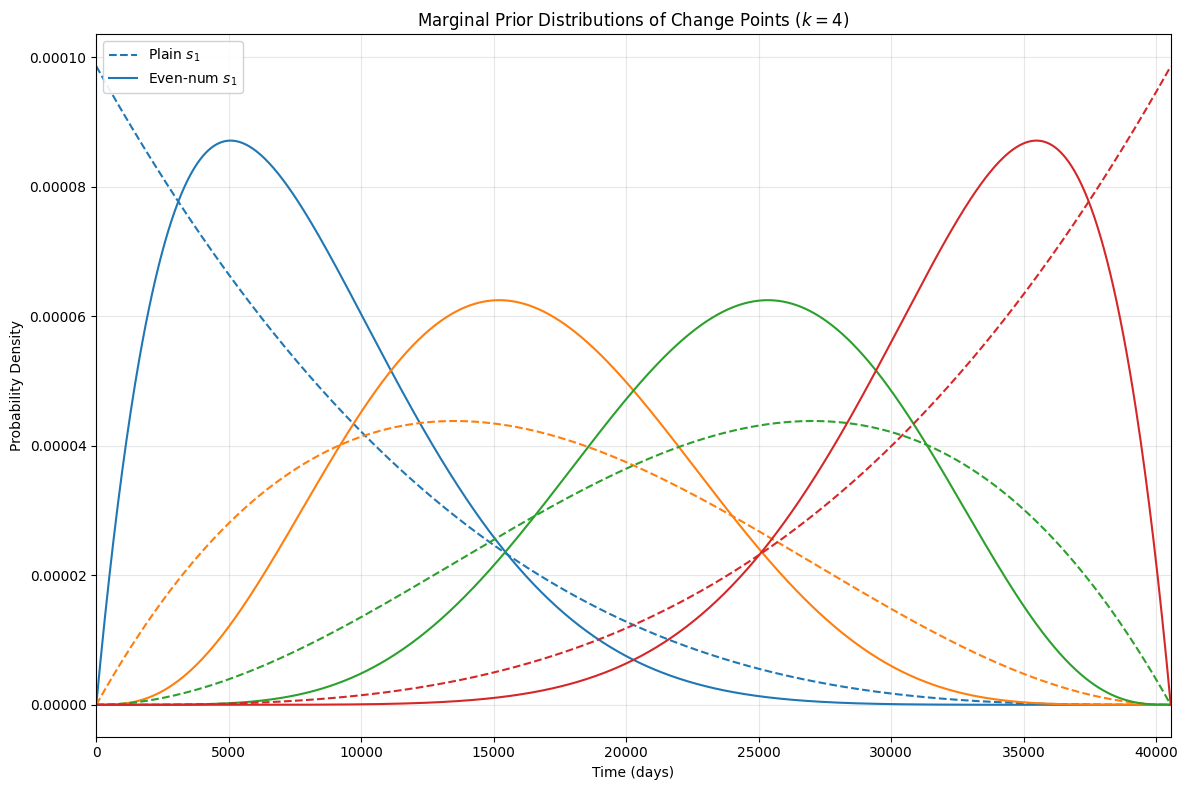

In [4]:
# params
L = 40550
k = 4
N_sim = 10000

s = np.linspace(0, L, 1000)

plt.figure(figsize=(12, 8))

for j in range(1, k + 1):
    # plain order
    dist_plain = beta(j, k - j + 1)
    
    # even numbered order
    dist_even = beta(2*j, 2*k - 2*j + 2)
    
    color = plt.cm.tab10(j-1)
    plt.plot(s, dist_plain.pdf(s/L)/L, color=color, linestyle='--', 
             label=f'Plain $s_{j}$' if j==1 else "")
    plt.plot(s, dist_even.pdf(s/L)/L, color=color, linestyle='-', 
             label=f'Even-num $s_{j}$' if j==1 else "")

plt.title(f'Marginal Prior Distributions of Change Points ($k={k}$)')
plt.xlabel('Time (days)')
plt.ylabel('Probability Density')
plt.xlim(0, L)
plt.legend(loc='upper left', framealpha=0.9)
plt.grid(True, alpha=0.3)

plt.savefig('figs/Ex2a.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()

### (b) PDF Derivation

To derive the even-numbered pdf we start with the fact that the plain ordered pdf for $2k+1$ points on the unit interval $[0, 1]$ is a constant

$$P(u_{(1)}, u_{(2)}, \dots, u_{(2k+1)}) = (2k + 1)!$$

This is valid only on the strictly ordered region $0 < u_{(1)} < u_{(2)} < \dots < u_{(2k+1)} < 1$.

For the even numbered pdf we only keep even-numbered order statistics $\hat{s}_j = u_{(2j)}$ so must marginalise the plain order pdf over all the other discarded points. We know that the points are ordered and on the unit interval $[0, 1]$ so the integral is

$$P(\hat{s}_1, \dots, \hat{s}_k) = \int_{0}^{\hat{s}_1} \int_{\hat{s}_1}^{\hat{s}_2} \dots \int_{\hat{s}_k}^{1} (2k + 1)! \, du_{(2k+1)} \dots du_{(3)} du_{(1)}$$

Because the integrand $(2k+1)!$ is a constant, each integral becomes the length of the interval between the 2 points on the bounds, or the gap $\hat{g}_j$ between them.

$$P(\hat{s}_1, \dots, \hat{s}_k) = (2k + 1)! (\hat{s}_1)(\hat{s}_2 - \hat{s}_1)\dots(1 - \hat{s}_k)$$

$$=  (2k + 1)! \prod_{j=1}^{k+1} \hat{g}_j$$

We now need to map this from the unit interval $[0, 1]$ to the actual timeline $[0, L]$. We are given the scaling relationship $s_j = L\hat{s}_j$ so can scale the gaps according to $\hat{g}_j = g_j / L$ and substitute this into the equation

$$P(\hat{s}_1, \dots, \hat{s}_k) = (2k + 1)! \prod_{j=1}^{k+1} \left( \frac{g_j}{L} \right)$$

Since $L$ is a constant it can be pulled out of the product

$$P(\hat{s}_1, \dots, \hat{s}_k) = \frac{(2k + 1)!}{L^{k+1}} \prod_{j=1}^{k+1} \left( g_j \right)$$

We must then apply the change of variables formula 

$$P(s_1, \dots, s_k) = P(\hat{s}_1, \dots, \hat{s}_k) \times \left| J \right|$$

where $|J|$ is the Jacobian determinant of the transformation. 

Since $s_j = L \hat{s}_j$, the inverse transformation is $\hat{s}_j = \frac{s_j}{L}$. Taking the derivative of each variable gives $\frac{\partial \hat{s}_j}{\partial s_j} = \frac{1}{L}$. The Jacobian determinant is then given by the product of the derivatives and since there are $k$ points,

$$\left| J \right| = \left( \frac{1}{L} \right)^k = \frac{1}{L^k}$$

This allows us to obtain the final pdf

$$\pi(s_1, s_2, \dots, s_k | M_k) = \frac{(2k+1)!}{L^{2k+1}} \prod_{j=1}^{k+1} g_j$$

$$\pi(s_1, s_2, \dots, s_k | M_k) \propto \prod_{j=1}^{k+1} g_j$$


## Exercise 3: The Constant Rate Model, $M_0$

From the instructions we know that the log likelihood is given by 
$$\log \mathcal{L}(\{I_i\} | \{s_j\}, \{h_j\}, M_k) = \sum_{i=1}^{N} \log h_0 - \int_{0}^{L} dt \, x(t)$$

Since $x(t) = h_0$ is a constant over the interval $L$
$$\log \mathcal{L}(\{I_i\} \mid h_0, M_0) = N \log(h_0) - h_0 L$$
The likelihood is therefore 
$$\mathcal{L}(\{I_i\} \mid h_0, M_0) = h_0^N \exp(-h_0 L)$$
From Exercise 2, the prior for the height parameters is universally given by a Gamma distribution $h_0 \sim \Gamma(\alpha, \beta)$ where $\alpha=1$ and $\beta=200$. This forms the probability density function
$$\pi(h_0 \mid M_0) = \frac{\beta^\alpha}{\Gamma(\alpha)} h_0^{\alpha-1} \exp(-\beta h_0)$$
Since $\alpha=1$ and $\Gamma(1) = 1$, the prior simplifies to 
$$\pi(h_0 \mid M_0) = \beta \exp(-\beta h_0) = 200 \exp(-200 h_0)$$

Applying Bayes' rule the unnormalised posterior $P^*$ is the product of the prior and likelihood
$$P^*(h_0 | \{I_i\}, M_0) = \beta \cdot h_0^N \exp(-h_0(L + \beta))$$

To calculate the true evidence $Z_0$ for model $M_0$, we must integrate $P^*(h_0 | \{I_i\}, M_0)$ over all possible values of $h_0$.
$$Z_0 = \int_{0}^{\infty} P^*(h_0 | \{I_i\}, M_0) \, dh_0$$

When evaluating $P^*(h_0) = \beta \cdot h_0^N \exp(-h_0(L+\beta))$ for our dataset where $N=191$ and $L=40550$, the probabilities evaluate to 0 due to an effect known as floating point underflow.

To safely resolve this underflow, we perform the computation in log-space. First, we take the logarithm of the unnormalised posterior:
$$f(h_0) = \log(P^*(h_0)) = \log(\beta) + N \log(h_0) - h_0(L + \beta)$$

We can then find the exact maximum of this log-posterior analytically. Taking the derivative with respect to $h_0$ and setting to zero yields the maximum a posteriori (MAP) height:
$$h_{\text{max}} = \frac{N}{L + \beta} \approx 0.00469$$

By evaluating the maximum log-posterior $C = f(h_{\text{max}})$, we can shift the posterior to peak at 1 and prevent the underflow problem when calculating the evidence.
$$P^*(h_0) = \exp(C) \times \exp(f(h_0) - C)$$

$$Z_0 = \exp(C) \int_{0}^{\infty} \exp(f(h_0) - C) \, dh_0$$

We can now use numerical integration with \texttt{scipy.integrate.quad} to evaluate the integral
$$\log Z_0 = C + \log\left( \int_{0}^{\infty} \exp(f(h_0) - C) \, dh_0 \right) \approx -1217$$

Log Evidence (ln Z0): -1217.09, error 8.621628018868622e-11


/var/folders/q5/m4w7tpr13hs_7wkk75z6xxb80000gn/T/ipykernel_2730/2062453617.py:9: RuntimeWarning: divide by zero encountered in log
  return np.log(beta) + N * np.log(h0) - h0 * (L + beta)


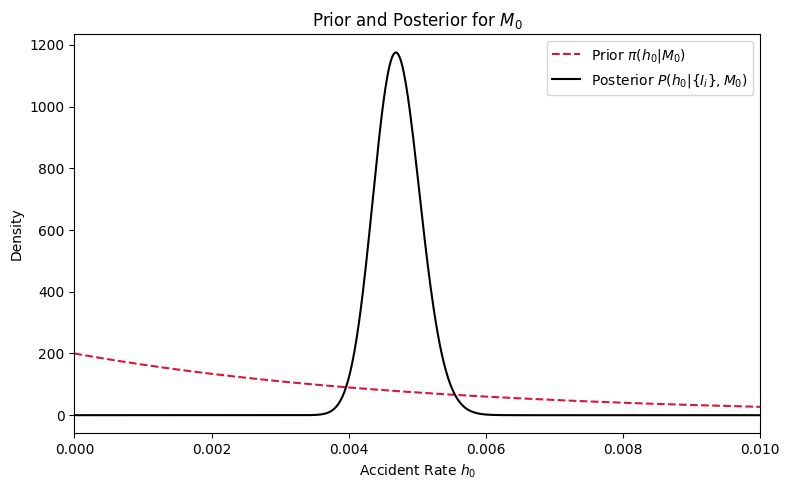

In [5]:
L = 40550
N = 191 
alpha = 1
beta = 200

# log unnormalised posterior
def log_unnorm_posterior(h0):
    # f(h0) = log(beta) + N*log(h0) - h0*(L + beta)
    return np.log(beta) + N * np.log(h0) - h0 * (L + beta)

# find c
h_max = N / (L + beta)
C = log_unnorm_posterior(h_max)

# shifted posterior: exp(f(h0) - C)
def shifted_posterior(h0):
    return np.exp(log_unnorm_posterior(h0) - C)

# numerical integration using scipy.integrate.quad
integral_value, error = integrate.quad(shifted_posterior, 0, 0.008)
log_Z0 = C + np.log(integral_value)
print(f"Log Evidence (ln Z0): {log_Z0:.2f}, error {error}")

# prior and posterior
h_vals = np.linspace(0, 0.015, 1000)
prior = (beta * np.exp(-beta * h_vals))
posterior = (np.exp(log_unnorm_posterior(h_vals) - log_Z0))

plt.figure(figsize=(8, 5))
plt.plot(h_vals, prior, label=r'Prior $\pi(h_0|M_0)$', linestyle='--', c='crimson')
plt.plot(h_vals, posterior, label=r'Posterior $P(h_0|\{I_i\},M_0)$', color='k')

plt.xlabel(r'Accident Rate $h_0$')
plt.ylabel('Density')
plt.title(r'Prior and Posterior for $M_0$')
plt.xlim(0, 0.01)
plt.legend()

plt.savefig('figs/Ex3a.pdf', bbox_inches='tight')
plt.tight_layout()
plt.show()


In [25]:
h_vals[np.argmax(posterior)]

np.float64(0.0046846846846846845)

## Exercise 4: The 1 Change Point Model, $M_1$

### (a) MCMC Analysis

In [6]:
# funcs for emcee

L = 40550
beta = 200

def log_prior(theta):
    s1, h0, h1 = theta

    # check bounds
    if not (0 < s1 < L) or h0 <= 0 or h1 <= 0:
        return -np.inf
    
    # log position prior 6/L^3 * s1 * (L - s_1)
    log_pos_prior = np.log(6) - 3*np.log(L) + np.log(s1) + np.log(L - s1)
    
    # log height prior 200 * exp(-200 * h)
    log_height_prior = 2 * np.log(beta) - beta * (h0 + h1)
    
    return log_pos_prior + log_height_prior

def log_likelihood(theta, y):
    s1, h0, h1 = theta
    
    # count how many accidents happened before and after the change point
    N0 = np.sum(y < s1)
    N1 = len(y) - N0
    
    # log likelihood N_0log(h_0) + N_1log(h_1) -( h_0s_1  h_1(L - s_1))
    return N0*np.log(h0) + N1*np.log(h1) -(h0*s1 + h1*(L - s1))

def log_posterior(theta, y):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, y)

In [7]:
# load data + constants
data = np.loadtxt('coal_mining_accident_data.dat').T.flatten()
N = 191
L = 40550
beta = 200
y = np.cumsum(data)

np.random.seed(68)

# MCMC settings
ndim = 3          # num params [s1, h0, h1]
nwalkers = 32     # num walkers
nsteps = 8000     # steps per walker

# init walkers
initial_s1 = np.random.uniform(1000, L - 1000, nwalkers) # - s1 [1000, L]
initial_h0 = np.random.normal(0.005, 0.001, nwalkers) # - h0, h1 based on constant model
initial_h1 = np.random.normal(0.005, 0.001, nwalkers)

# combine into a (nwalkers, ndim) array
p0 = np.vstack([initial_s1, initial_h0, initial_h1]).T

# all heights positive
p0[:, 1:] = np.abs(p0[:, 1:]) 

# run sampler
print("Running MCMC...")
sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior, args=(y,))
sampler.run_mcmc(p0, nsteps, progress=True)
print('Finished')

Running MCMC...


100%|██████████| 8000/8000 [00:03<00:00, 2438.20it/s]

Finished


Autocorrelation time for [s1, h0, h1]: [46.54210029 51.9312467  44.46440178]


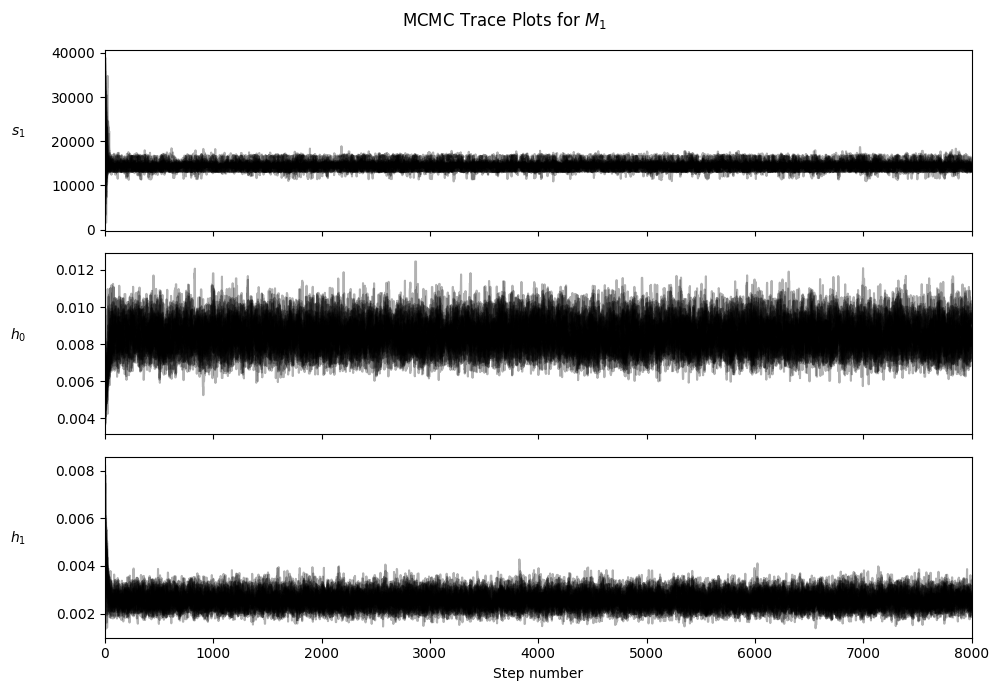

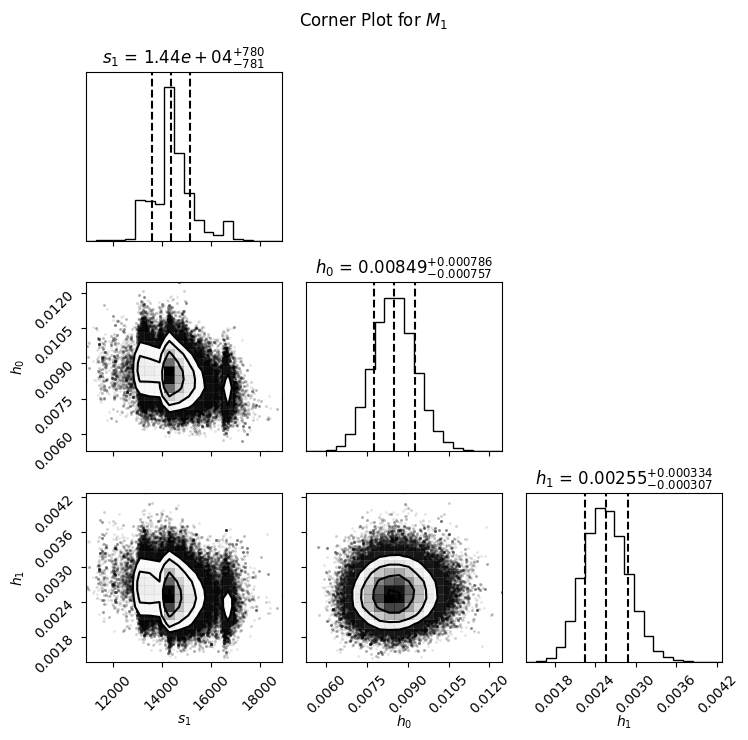

In [8]:
tau = sampler.get_autocorr_time(quiet=True)
print(f"Autocorrelation time for [s1, h0, h1]: {tau}")

# trace plots
# This plots the path of every walker over time to check for convergence
fig, axes = plt.subplots(3, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["$s_1$", "$h_0$", "$h_1$"]
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i], rotation=0)
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Step number")
fig.suptitle(r"MCMC Trace Plots for $M_1$")

plt.tight_layout()
plt.savefig('figs/Ex4a_traces.pdf', bbox_inches='tight')
plt.show()

# get results
burnin = 500
flat_samples = sampler.get_chain(discard=burnin, flat=True)

# corner plot
fig = corner.corner(
    flat_samples, labels=labels, truths=None,
    quantiles=[0.16, 0.5, 0.84], # Shows the 1-sigma uncertainty regions
    show_titles=True, title_kwargs={"fontsize": 12}, title_fmt=".3g"
)
fig.suptitle(r"Corner Plot for $M_1$")

plt.tight_layout()
plt.savefig('figs/Ex4a_corner.pdf', bbox_inches='tight')
plt.show()

### (b) Savage-Dickey Density Ratio

Prior density at delta_h = 0: 100.00
Posterior density at delta_h = 0 (KDE): 9.48e-129
Bayes Factor B_01: 9.48e-131


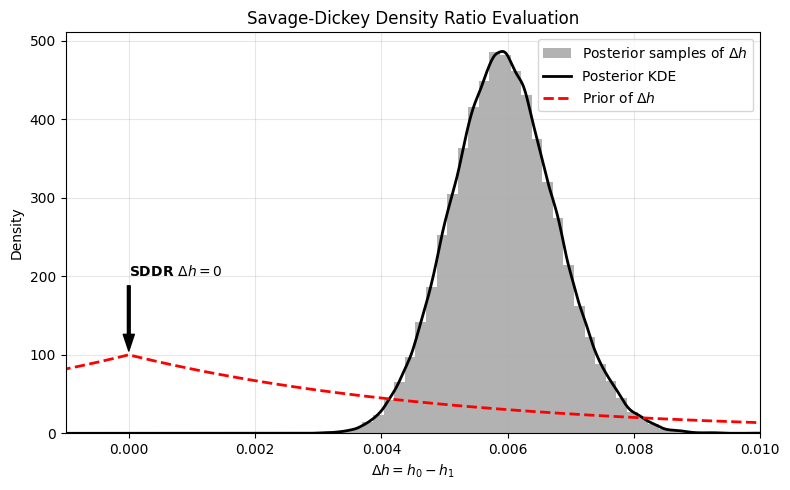

In [9]:

# get samples from mcmc
h0_samples = flat_samples[:, 1]
h1_samples = flat_samples[:, 2]
delta_h = h0_samples - h1_samples

# calc prior
beta = 200
prior_at_zero = beta / 2.0 

# kde of posterior
kde = gaussian_kde(delta_h)
posterior_at_zero = kde(0.0)[0]

# bayes factor
B_01 = posterior_at_zero / prior_at_zero

print(f"Prior density at delta_h = 0: {prior_at_zero:.2f}")
print(f"Posterior density at delta_h = 0 (KDE): {posterior_at_zero:.2e}")
print(f"Bayes Factor B_01: {B_01:.2e}")



# plot
plt.figure(figsize=(8, 5))
plt.grid(alpha = 0.3)
# posterior histogram + kde
plt.hist(delta_h, bins=50, density=True, alpha=0.6, color='gray', label=r'Posterior samples of $\Delta h$')
x_grid = np.linspace(-0.002, np.max(delta_h) + 0.002, 1000)
plt.plot(x_grid, kde(x_grid), 'k-', lw=2, label='Posterior KDE')

# prior
prior_pdf = (beta / 2.0) * np.exp(-beta * np.abs(x_grid))
plt.plot(x_grid, prior_pdf, 'r--', lw=2, label=r'Prior of $\Delta h$')

# Highlight the evaluation point for SDDR
# plt.vlines(x=0, ymin =0, ymax = 100, color = 'k', linestyle = '--')
plt.annotate(r'SDDR $\Delta h = 0$', xy=(0, 100), xytext=(0.000, 200), 
             arrowprops=dict(facecolor='k', shrink=0.05, width=2, headwidth=8),
             color='k',
             fontweight='bold')

plt.xlabel(r'$\Delta h = h_0 - h_1$')
plt.ylabel('Density')
plt.title('Savage-Dickey Density Ratio Evaluation')
plt.xlim(-0.001, 0.01)

plt.legend()
plt.tight_layout()
plt.savefig('figs/Ex4b.pdf', bbox_inches='tight')
plt.show()

### (d) Nested Sampling

In [12]:
from scipy.stats import beta, gamma
np.random.seed(68)

# nested sampling
data = np.loadtxt('coal_mining_accident_data.dat').T.flatten()
L = 40550
N = 191
accident_times = np.cumsum(data)

def ptform(u):
    """Prior transform function for dynesty"""
    # s1 prior is Beta(2, 2) distribution scaled by L from before
    s1 = beta.ppf(u[0], 2, 2) * L
    
    # h0 and h1 priors are Gamma(1, 200)
    h0 = gamma.ppf(u[1], a = 1, scale=1/200)
    h1 = gamma.ppf(u[2], a = 1, scale=1/200)
    
    return np.array([s1, h0, h1])

def loglike(theta):
    """Log-Likelihood function"""
    s1, h0, h1 = theta
    
    # number of accidents before and after s1
    n0 = np.sum(accident_times < s1)
    n1 = N - n0
    
    # log-likelihood
    ll = n0 * np.log(h0) + n1 * np.log(h1) - s1 * h0 - (L - s1) * h1
    return ll

# dynesty
sampler = dynesty.NestedSampler(loglike, ptform, ndim=3, nlive=1000, bound='multi', sample='rwalk')
sampler.run_nested(dlogz=0.1, print_progress=True)

# results
results = sampler.results
logZ1 = results.logz[-1]
logZ1_err = results.logzerr[-1]

print(rf"Log Evidence for $M_1$: {logZ1:.2f} +/- {logZ1_err:.2f}")



11434it [00:24, 471.57it/s, +1000 | bound: 8 | nc: 1 | ncall: 216587 | eff(%):  5.768 | loglstar:   -inf < -1179.414 <    inf | logz: -1188.528 +/-  0.085 | dlogz:  0.000 >  0.100]

Log Evidence for $M_1$: -1188.53 +/- 0.10


In [13]:
logZ0 = -1217.09
# You can evaluate your integral from 3a to get the logZ0 and calculate the odds:
log_B10 = logZ1 - logZ0
prior_odds = 3.0  # From Poisson(3) prior on models: P(M1)/P(M0) = 3
log_posterior_odds = log_B10 + np.log(prior_odds)

print(f'Log Bayes Factor is {log_B10}')
print(f'Log Posterior odds: {log_posterior_odds}')

Log Bayes Factor is 28.562241855769116
Log Posterior odds: 29.660854144437227


## Exercise 5: The $k$ Change Point Models, $M_k$

### (b) RJMCMC Plots

In [5]:
import importlib
import RJMCMC
importlib.reload(RJMCMC)

np.random.seed(68)
data = np.loadtxt('coal_mining_accident_data.dat').T.flatten()

sampler = RJMCMC.RJMCMC(data)
sampler.run_mcmc(num_iter=300000)


100%|██████████| 300000/300000 [01:12<00:00, 4138.69it/s]

Height change moves attempted 8.6% of the time with an acceptance fraction of 0.523
Position change moves attempted 8.6% of the time with an acceptance fraction of 0.214
Birth moves attempted 38.1% of the time with an acceptance fraction of 0.233
Death moves attempted 44.8% of the time with an acceptance fraction of 0.199


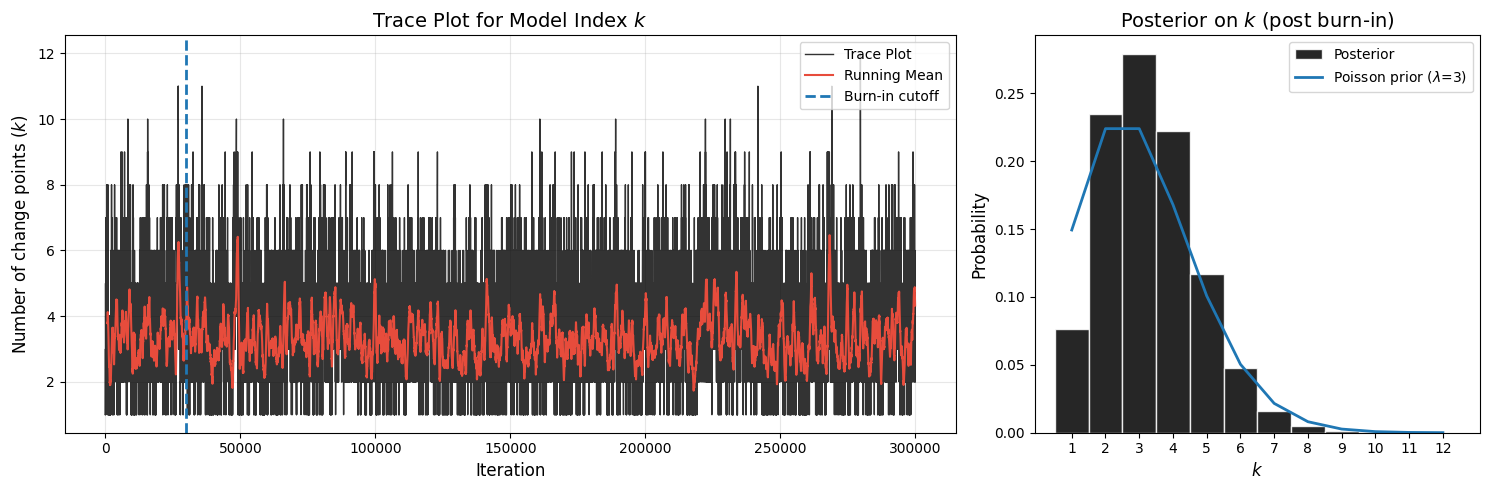

MAP k (post burn-in): 3
k=3: 0.2788
k=2: 0.2349
k=4: 0.2225
k=5: 0.1166
k=1: 0.0764
k=6: 0.0475
k=7: 0.0161
k=8: 0.0051


In [6]:
from scipy.stats import poisson
# posterior on k (computed after burn-in)
k_values_all = np.array([(len(state) - 1) // 2 for state in sampler.chain])
burn_in = int(0.1 * len(k_values_all))
k_values = k_values_all[burn_in:]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

window = 700
running_avg = np.convolve(k_values_all, np.ones(window) / window, mode='valid')

ax1.plot(k_values_all, color='k', linewidth=1, alpha=0.8, label='Trace Plot')
ax1.plot(np.arange(window - 1, len(k_values_all)), running_avg, color='#e74c3c', linewidth=1.5, label=f'Running Mean')
ax1.axvline(burn_in, color='tab:blue', ls='--', lw=2.0, label='Burn-in cutoff')

ax1.set_xlabel('Iteration', fontsize=12)
ax1.set_ylabel('Number of change points ($k$)', fontsize=12)
ax1.set_title('Trace Plot for Model Index $k$', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right')

bins = np.arange(k_values.min(), k_values.max() + 2) - 0.5
ax2.hist(k_values, bins=bins, density=True, color='k', edgecolor='white', alpha=0.85, label='Posterior')

# overlay Poisson prior on k for comparison
k_plot = np.arange(int(k_values.min()), int(k_values.max()) + 1)
prior_vals = poisson(mu=sampler.lam).pmf(k_plot)
ax2.plot(k_plot, prior_vals, color='tab:blue', lw=2, label=fr'Poisson prior ($\lambda$={sampler.lam:g})')

ax2.set_xticks(range(int(k_values.min()), int(k_values.max()) + 1))
ax2.set_xlabel('$k$', fontsize=12)
ax2.set_ylabel('Probability', fontsize=12)
ax2.set_title('Posterior on $k$ (post burn-in)', fontsize=14)
ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig('figs/Ex5b.pdf', bbox_inches='tight')
plt.show()

# MAP and top probabilities
counts = np.bincount(k_values)
map_k = int(np.argmax(counts))
print(f'MAP k (post burn-in): {map_k}')

probs = counts / counts.sum()
for k in np.argsort(probs)[::-1][:8]:
    if probs[k] > 0:
        print(f'k={k}: {probs[k]:.4f}')


The RJMCMC was run for 300,000 iterations. The trace plot in \Cref{fig:5b} shows that the chain explored a wide range of models and mixed well, staying mostly between between $k=2$ and $k=5$, occasionally jumping as high as $k=11$. The chain converged rapidly with the running mean stabilising within the first few thousand iterations, so only the first 10\% of samples were discarded as burn in. The posterior distribution on $k$ peaks at $k=3$ ($P \approx 0.28$), which is the maximum a priori estimate, followed by $k=2$ ($P \approx 0.23$) and $k=4$ ($P \approx 0.22$). The posterior is broadly consistent with the Poisson prior, shown in blue, but is more strongly peaked at $k=3$ and slightly favours larger values of $k$.


### (c) Model Averaging

In [7]:
# make k chain
burn = int(0.1 * len(sampler.chain))
chain = sampler.chain[burn:]
k_chain = np.array([(len(state) - 1) // 2 for state in chain], dtype=float)

# fast autocorrelation function (FFT)
def autocorr_fft(x):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    f = np.fft.rfft(np.concatenate([x, np.zeros_like(x)]))
    acf = np.fft.irfft(f * np.conjugate(f))[:n]
    acf /= acf[0]
    return acf

# integrated autocorrelation time
def integrated_time(x, c=5.0, max_lag=None):
    acf = autocorr_fft(x)
    if max_lag is None:
        max_lag = len(acf) // 2
    tau = 1.0
    for m in range(1, max_lag):
        if acf[m] <= 0:
            break
        tau = 1 + 2*np.sum(acf[1:m+1])
        if m > c * tau:
            break
    return tau, acf

tau_k, acf_k = integrated_time(k_chain)
print(f"Integrated autocorrelation time for k: tau ≈ {tau_k:.1f} iterations")
print(f"Suggested thinning: {max(1, int(np.ceil(tau_k/2)))} to {int(np.ceil(tau_k))}")
print(f"Effective sample size (for k): ~ {len(k_chain)/tau_k:.0f}")

Integrated autocorrelation time for k: tau ≈ 195.1 iterations
Suggested thinning: 98 to 196
Effective sample size (for k): ~ 1384


In [8]:
L = sampler.duration 
t_grid = np.linspace(0, L, 500)

# thinning
thin = 1
thin_chain = chain[::thin]

# x(t) eval
all_rates = np.zeros((len(thin_chain), len(t_grid)))

for i, state in enumerate(thin_chain):
    k = (len(state) - 1) // 2
    s = state[:k]      # change point positions
    h = state[k:]      # segment heights
    
    idx = np.searchsorted(s, t_grid)
    all_rates[i, :] = h[idx]

# calc error
median_rate = np.percentile(all_rates, 50, axis=0)
p25 = np.percentile(all_rates, 25, axis=0)
p75 = np.percentile(all_rates, 75, axis=0)
p05 = np.percentile(all_rates, 5, axis=0)
p95 = np.percentile(all_rates, 95, axis=0)


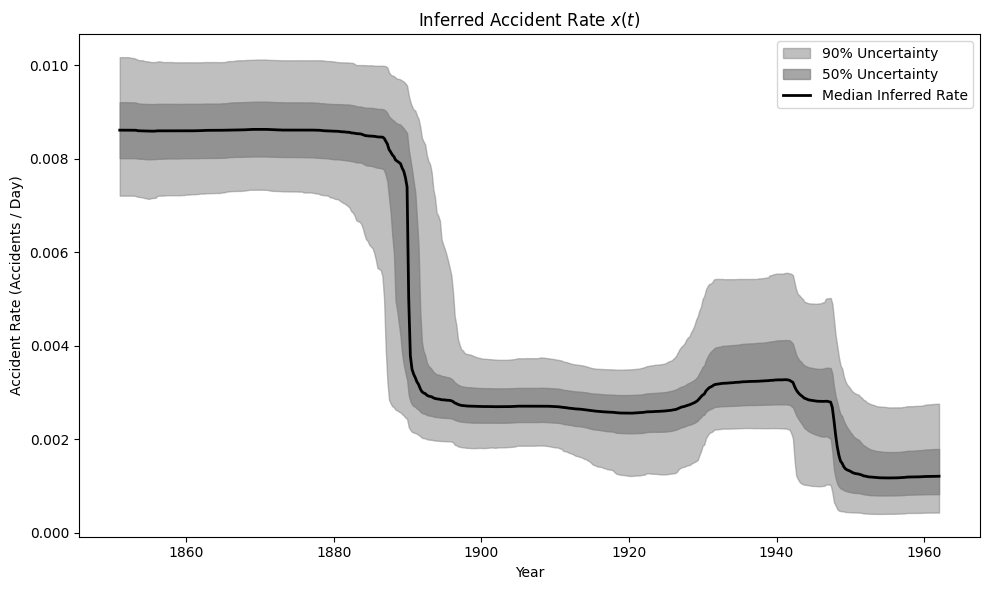

In [9]:
# plot
t_grid_years = 1851 + (t_grid / 365.25)

plt.figure(figsize=(10, 6))

plt.fill_between(t_grid_years, p05, p95, color='grey', alpha=0.5, label='90% Uncertainty')
plt.fill_between(t_grid_years, p25, p75, color='grey', alpha=0.7, label='50% Uncertainty')
plt.plot(t_grid_years, median_rate, color='k', linewidth=2, label='Median Inferred Rate')

plt.xlabel('Year')
plt.ylabel('Accident Rate (Accidents / Day)')
plt.title('Inferred Accident Rate $x(t)$')
plt.legend()
# plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('figs/Ex5c.pdf', bbox_inches='tight')
plt.show()
